# HPOA Overview

(phenotype.hpoa) – Disease–Phenotype Annotations

This dataset contains curated associations between diseases and phenotypes.

- Diseases are identified using external databases:
  - OMIM (e.g., OMIM:154700)
  - ORPHANET (e.g., ORPHA:558)

- Phenotypes are represented using HPO terms:
  - Example: HP:0001250 (Seizures)

Each row represents one association between a disease and a phenotype, along with metadata such as evidence and frequency.

## Validation and Comparison with HOOM

HPOA can be used as a reference dataset to validate disease–phenotype relationships derived from HOOM.

While HOOM integrates HPO and ORDO into a unified ontology, the underlying associations may differ in:
- coverage (missing or additional links)
- representation (ontology relations vs. flat annotations)
- update frequency

By comparing HOOM-derived links with HPOA annotations, we can:
- verify that key associations are preserved
- identify discrepancies or gaps
- better understand the impact of using an integrated ontology vs. a curated annotation file

## Summary
- This dataset provides direct disease → phenotype associations.
- It is the primary source of links between:
  - OMIM / ORPHA diseases
  - HPO phenotypes

- Unlike HPO or ORDO:
  - This is NOT an ontology
  - It is a flat annotation table

- It can be used to:
  1. Build disease–phenotype edges
  2. Map diseases to ORDO
  3. Support similarity and prediction tasks
  4. Validate disease–phenotype relationships derived from HOOM



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from raresim.utils.paths import ONTOLOGY_DIR

Loading phenotype.hpoa...


/var/folders/ky/pr55mcfd783dh2zp5_qyl8mh0000gn/T/ipykernel_95565/2584983763.py:2: DtypeWarning: Columns (0: 2, 1: 6, 2: 8, 3: 9) have mixed types. Specify dtype option on import or set low_memory=False.
  hpoa = pd.read_csv(


File loaded.
Rows: 258166
Columns: 12

Preview:
   database_id                                   disease_name  qualifier  \
0  database_id                                   disease_name  qualifier   
1  OMIM:619340  Developmental and epileptic encephalopathy 96        NaN   
2  OMIM:619340  Developmental and epileptic encephalopathy 96        NaN   
3  OMIM:619340  Developmental and epileptic encephalopathy 96        NaN   
4  OMIM:619340  Developmental and epileptic encephalopathy 96        NaN   

       hpo_id      reference  evidence  onset  frequency  sex  modifier  \
0      hpo_id      reference  evidence  onset  frequency  sex  modifier   
1  HP:0011097  PMID:31675180       PCS    NaN        1/2  NaN       NaN   
2  HP:0002187  PMID:31675180       PCS    NaN        1/1  NaN       NaN   
3  HP:0001518  PMID:31675180       PCS    NaN        1/2  NaN       NaN   
4  HP:0032792  PMID:31675180       PCS    NaN        1/2  NaN       NaN   

   aspect                biocuration  
0  as

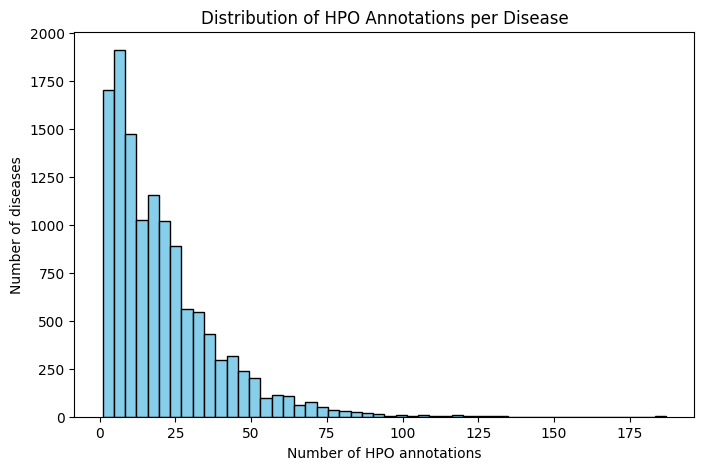


Top 10 diseases with most HPO annotations:
database_id
ORPHA:904       187
OMIM:619475     186
OMIM:619503     155
ORPHA:261552    147
OMIM:180849     143
ORPHA:2152      140
OMIM:300855     134
OMIM:601803     133
ORPHA:567       131
ORPHA:261537    129
Name: hpo_id, dtype: int64


In [2]:
print("Loading phenotype.hpoa...")
hpoa = pd.read_csv(
    f"{ONTOLOGY_DIR}/phenotype.hpoa.owl",
    sep="\t",
    comment="#",
    header=None
)

print("File loaded.")

# Check shape
print(f"Rows: {hpoa.shape[0]}")
print(f"Columns: {hpoa.shape[1]}")

# Official column names for phenotype.hpoa
hpoa.columns = [
    "database_id", # Disease identifier (OMIM or ORPHA)
    "disease_name",
    "qualifier",
    "hpo_id",
    "reference",
    "evidence",
    "onset",
    "frequency",
    "sex",
    "modifier",
    "aspect",
    "biocuration"
]

print("\nPreview:")
print(hpoa.head())

# Basic counts
print("\nBasic statistics")
print(f"Unique diseases: {hpoa['database_id'].nunique()}")
print(f"Unique HPO terms: {hpoa['hpo_id'].nunique()}")
print(f"Unique evidence codes: {hpoa['evidence'].nunique()}")

# Disease source counts
source_counts = hpoa["database_id"].str.split(":").str[0].value_counts()
print("\nDisease source prefixes:") # OMIM: Mendelian diseases or ORPHA: rare diseases (linked to ORDO)
print(source_counts)

# Number of HPO annotations per disease
ann_per_disease = hpoa.groupby("database_id")["hpo_id"].count()
print(f"\nAverage annotations per disease: {ann_per_disease.mean():.2f}")
print(f"Max annotations for one disease: {ann_per_disease.max()}")

# Plot distribution of annotations per disease
plt.figure(figsize=(8, 5))
plt.hist(ann_per_disease, bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of HPO Annotations per Disease")
plt.xlabel("Number of HPO annotations")
plt.ylabel("Number of diseases")
plt.show()

# Top diseases with most phenotype annotations
print("\nTop 10 diseases with most HPO annotations:")
print(ann_per_disease.sort_values(ascending=False).head(10))

In [3]:
def print_hpoa_disease(disease_id, df):
    rows = df[df["database_id"] == disease_id]
    
    if rows.empty:
        print(f"Disease '{disease_id}' not found.")
        return
    
    print("\n==============================")
    print("HPOA DISEASE OVERVIEW")
    print("==============================")
    print(f"Disease ID: {disease_id}")
    print(f"Disease name: {rows['disease_name'].iloc[0]}")
    print(f"Number of phenotype annotations: {len(rows)}")
    
    print("\nPhenotypes:")
    for hp in rows["hpo_id"].head(20):
        print(f"  - {hp}")
    if len(rows) > 20:
        print(f"  ... ({len(rows)} total)")
    
    print("\nEvidence codes:") # Evidence codes indicate how reliable an association is (e.g., clinical observation vs. inferred).
    print(rows["evidence"].value_counts())
    print("==============================\n")

In [4]:
print_hpoa_disease("OMIM:154700", hpoa)


HPOA DISEASE OVERVIEW
Disease ID: OMIM:154700
Disease name: Marfan syndrome
Number of phenotype annotations: 70

Phenotypes:
  - HP:0000483
  - HP:0001377
  - HP:0000486
  - HP:0005136
  - HP:0001371
  - HP:0003199
  - HP:0025586
  - HP:0000518
  - HP:0008132
  - HP:0002816
  - HP:0002616
  - HP:0001647
  - HP:0000678
  - HP:0008138
  - HP:0001840
  - HP:0001763
  - HP:0000278
  - HP:0007800
  - HP:0001765
  - HP:0002751
  ... (70 total)

Evidence codes:
evidence
PCS    47
IEA    18
TAS     5
Name: count, dtype: int64

